<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Emergent_Polymer_Discovery_Platform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Emergent Polymer Discovery Platform
This notebook implements a multi-agent system to search for novel polymer combinations using evolutionary algorithms.

In [1]:
import random
import numpy as np
import pandas as pd

class PolymerAgent:
    def __init__(self, name, role):
        self.name = name
        self.role = role

    def evaluate(self, polymer):
        pass

class Chemist(PolymerAgent):
    def evaluate(self, polymer):
        # Simulates chemical stability and bonding potential
        return sum(polymer.values()) * 0.8

class MaterialsScientist(PolymerAgent):
    def evaluate(self, polymer):
        # Focuses on Strength and Flexibility
        return (polymer.get('monomer_a', 0) * 1.5) + (polymer.get('monomer_b', 0) * 0.5)

class ManufacturingEngineer(PolymerAgent):
    def evaluate(self, polymer):
        # Focuses on scalability/feasibility
        return 100 - (polymer.get('monomer_c', 0) * 2)

class CostAnalyst(PolymerAgent):
    def evaluate(self, polymer):
        # Focuses on economic viability
        return 1.0 / (1.0 + sum(polymer.values()) * 0.1)

Discovery complete.


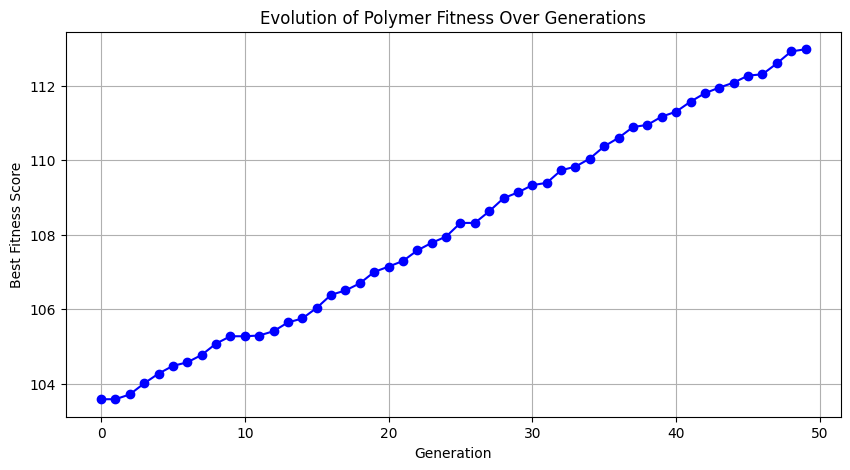

In [3]:
import matplotlib.pyplot as plt

def genetic_algorithm_search(iterations=50, population_size=10):
    agents = [
        Chemist("Dr. Bond", "Chemist"),
        MaterialsScientist("Sarah Smith", "Materials Scientist"),
        ManufacturingEngineer("Mike Gear", "Manufacturing"),
        CostAnalyst("Jane Doe", "Finance")
    ]

    population = [{'monomer_a': random.random(), 'monomer_b': random.random(), 'monomer_c': random.random()} for _ in range(population_size)]
    history = []

    for i in range(iterations):
        scores = []
        for p in population:
            fitness = sum([a.evaluate(p) for a in agents])
            scores.append((fitness, p))

        scores.sort(key=lambda x: x[0], reverse=True)
        history.append(scores[0][0])

        parent1 = scores[0][1]
        parent2 = scores[1][1]

        new_pop = [parent1, parent2]
        for _ in range(population_size - 2):
            child = {
                'monomer_a': (parent1['monomer_a'] + parent2['monomer_a'])/2 + random.uniform(-0.1, 0.1),
                'monomer_b': (parent1['monomer_b'] + parent2['monomer_b'])/2 + random.uniform(-0.1, 0.1),
                'monomer_c': (parent1['monomer_c'] + parent2['monomer_c'])/2 + random.uniform(-0.1, 0.1)
            }
            new_pop.append(child)
        population = new_pop

    return scores[0], history

best_polymer_data, fitness_history = genetic_algorithm_search()
print("Discovery complete.")

plt.figure(figsize=(10, 5))
plt.plot(fitness_history, marker='o', linestyle='-', color='b')
plt.title('Evolution of Polymer Fitness Over Generations')
plt.xlabel('Generation')
plt.ylabel('Best Fitness Score')
plt.grid(True)
plt.show()